In [ ]:
 import pandas as pd
import CTM

df = pd.read_csv('dft_rawcount_local_authority_id_85.csv', delimiter=',',low_memory=False,header=1,names=['count_point_id','direction_of_travel','year','count_date','hour','region_id','region_name','local_authority_id','local_authority_name','road_name','road_type','start_junction_road_name','end_junction_road_name','easting','northing','latitude','longitude','link_length_km','link_length_miles','pedal_cycles','two_wheeled_motor_vehicles','cars_and_taxis','buses_and_coaches','lgvs','hgvs_2_rigid_axle','hgvs_3_rigid_axle','hgvs_4_or_more_rigid_axle','hgvs_3_or_4_articulated_axle','hgvs_5_articulated_axle','hgvs_6_articulated_axle','all_hgvs','all_motor_vehicles']
)
filtered_df=df[(df['count_point_id']==810896) | (df['count_point_id']==57603) | (df['count_point_id']==944412)]
directions_of_travel=filtered_df['direction_of_travel'].unique()
East_travelling_df=filtered_df[filtered_df['direction_of_travel']=='E']
West_travelling_df=filtered_df[filtered_df['direction_of_travel']=='W']

def get_moving_traffic_data(df,count_point_id,type):
    filtered_df=df[df['count_point_id']==count_point_id]
    travelling_df=filtered_df[filtered_df['direction_of_travel']==type]
    return travelling_df





for type in filtered_df['direction_of_travel'].unique():
    print(type)
    directed_df=filtered_df[filtered_df['direction_of_travel']==type]
    print(get_moving_traffic_data(directed_df,57603,type)[['count_point_id','all_motor_vehicles','direction_of_travel']])
    print(get_moving_traffic_data(directed_df,810896,type)[['count_point_id','all_motor_vehicles','direction_of_travel']])
    print(get_moving_traffic_data(directed_df,944412,type)[['count_point_id','all_motor_vehicles','direction_of_travel']])
    

model=CTM()



# East_travelling_df=get_east_moving_traffic_data(df,57603)
# West_travelling_df=get_west_moving_traffic_data(df,57603)
# print(East_travelling_df[['hour','all_motor_vehicles','link_length_miles']].sort_values(by='hour'))
# print(West_travelling_df[['hour','all_motor_vehicles','direction_of_travel']].sort_values(by='hour'))




S
       count_point_id  all_motor_vehicles direction_of_travel
13919           57603                 918                   S
13920           57603                1057                   S
13922           57603                 734                   S
13923           57603                 696                   S
13926           57603                 421                   S
13928           57603                 569                   S
13930           57603                 865                   S
13933           57603                 705                   S
13935           57603                 709                   S
13938           57603                 906                   S
13939           57603                 712                   S
13941           57603                 650                   S
13944           57603                 576                   S
13946           57603                 667                   S
13948           57603                 643                   S
13951 

# testing CTM model

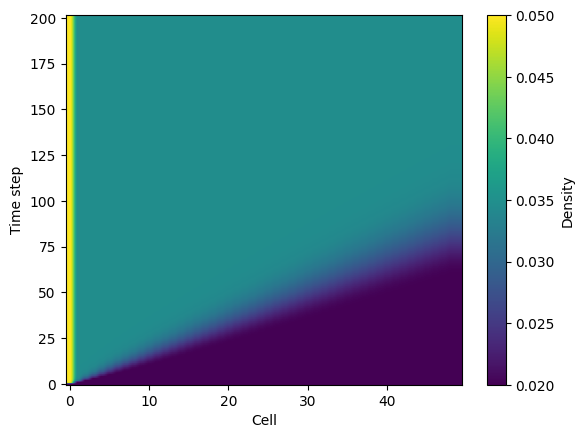

In [4]:
# Road setup
import numpy as np
import CTM
N = 50                          # number of cells
road_length = 1000              # metres
cell_widths = np.full(N, road_length / N)  # uniform 20m cells

# Traffic parameters
v_free = 30                     # m/s (about 108 km/h, motorway speed)
jam_density = 0.15              # vehicles per metre (1 vehicle per ~7m)
max_flow = v_free * jam_density / 4  # Greenshields peak flow

# Initial density — light traffic everywhere
density_init = np.full(N, 0.02)  # 0.02 veh/m, well below critical

# Inlet density — slightly higher to push traffic in
inlet_density = 0.05

model = CTM.CTM_model(cell_widths, density_init, jam_density, max_flow, v_free)
model.recursive_stepping(0, inlet_density, total_steps=200)

import matplotlib.pyplot as plt
plt.imshow(np.array(model.history), aspect='auto', origin='lower')
plt.xlabel('Cell'); plt.ylabel('Time step'); plt.colorbar(label='Density')
plt.show()